<a href="https://colab.research.google.com/github/ciril7/AI-ML-Internship/blob/main/Day%204/Image_Preprocessing_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
zip_path = "/content/football.zip"

In [2]:
import os
import cv2
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob

# Extract dataset
zip_path = "/content/football.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

# Collect image paths
extensions = ['*.jpg','*.jpeg','*.png','*.bmp','*.webp']

image_paths = []

for ext in extensions:
    image_paths.extend(
        glob(os.path.join(extract_path,'**',ext), recursive=True)
    )

print("Total Images:", len(image_paths))

Dataset Extracted Successfully
Total Images: 100


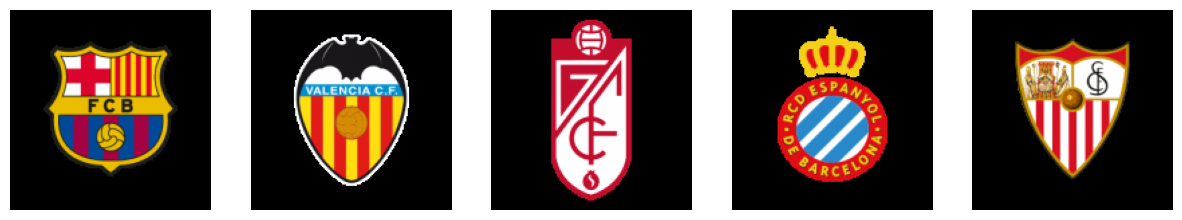

In [3]:
plt.figure(figsize=(15,5))

for i in range(5):
    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [4]:
image_info = []

for path in image_paths:

    img = cv2.imread(path)

    if img is not None:
        h,w,c = img.shape

        image_info.append([
            os.path.basename(path),
            h,
            w,
            c
        ])

df = pd.DataFrame(
    image_info,
    columns=["Image","Height","Width","Channels"]
)

df.head(10)

,Image,Height,Width,Channels
0,barcelona.png,150,150,3
1,valencia.png,150,150,3
2,granada.png,150,150,3
3,espanyol.png,150,150,3
4,sevilla.png,150,150,3
5,osasuna.png,150,150,3
6,rayo-vallecano.png,150,150,3
7,villarreal.png,150,150,3
8,levante.png,150,150,3
9,real-madrid.png,150,150,3


In [5]:
df.to_csv("image_dimensions.csv", index=False)

In [6]:
resized_images = []

for path in image_paths:

    img = cv2.imread(path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        resized = cv2.resize(img, (224, 224))

        resized_images.append(resized)

print("Total Resized Images:", len(resized_images))

Total Resized Images: 100


In [7]:
rgb_images = []
gray_images = []
hsv_images = []

for path in image_paths:

    img = cv2.imread(path)

    if img is not None:

        # BGR to RGB
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # RGB to Grayscale
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

        # RGB to HSV
        hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

        rgb_images.append(rgb)
        gray_images.append(gray)
        hsv_images.append(hsv)

print("RGB Images :", len(rgb_images))
print("Grayscale Images :", len(gray_images))
print("HSV Images :", len(hsv_images))

RGB Images : 100
Grayscale Images : 100
HSV Images : 100


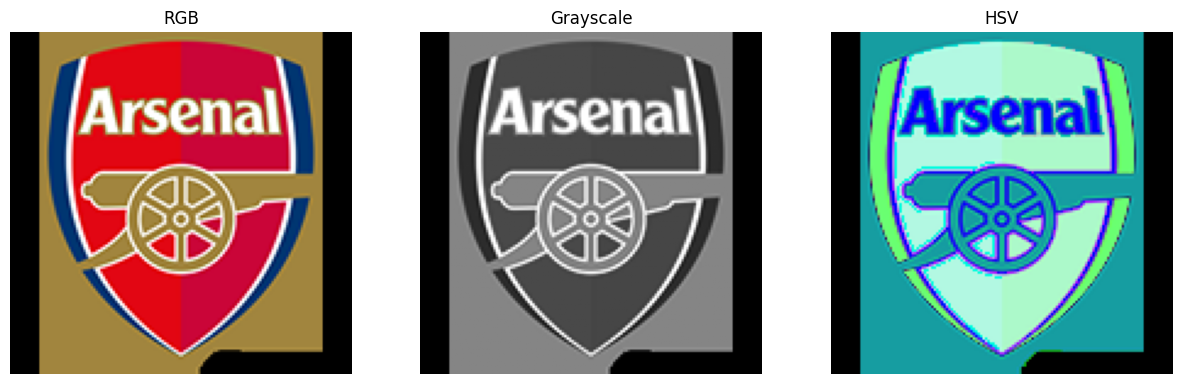

In [14]:
sample_index = 80

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(rgb_images[sample_index])
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray_images[sample_index], cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hsv_images[sample_index])
plt.title("HSV")
plt.axis("off")

plt.show()

In [9]:
normalized = resized / 255.0

print("Before Normalization")
print("Minimum Pixel Value :", resized.min())
print("Maximum Pixel Value :", resized.max())

print("\nAfter Normalization")
print("Minimum Pixel Value :", normalized.min())
print("Maximum Pixel Value :", normalized.max())

Before Normalization
Minimum Pixel Value : 0
Maximum Pixel Value : 255

After Normalization
Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


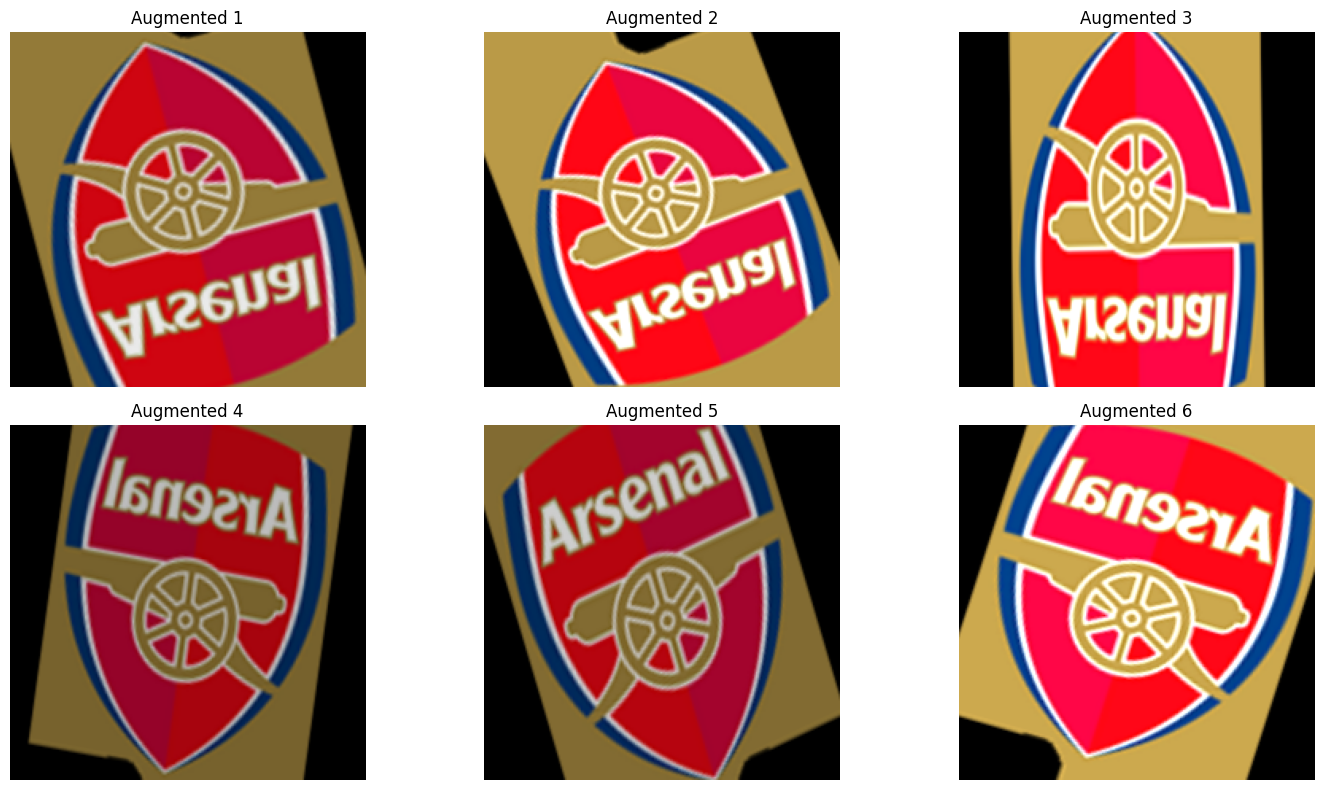

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import cv2
import matplotlib.pyplot as plt

sample = cv2.imread(image_paths[80])
sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)
sample = cv2.resize(sample, (224,224))


datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.7,1.3])


img = np.expand_dims(sample, axis=0)

augmented_images = datagen.flow(
    img,
    batch_size=1
)


plt.figure(figsize=(15,8))

for i in range(6):

    batch = next(augmented_images)

    plt.subplot(2,3,i+1)
    plt.imshow(batch[0].astype("uint8"))
    plt.axis("off")
    plt.title(f"Augmented {i+1}")

plt.tight_layout()
plt.show()

In [11]:
import cv2
import numpy as np

def preprocess_image(image_path):

    # Read image
    img = cv2.imread(image_path)

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to 224×224
    img = cv2.resize(img, (224, 224))

    # Normalize pixel values (0-1)
    img = img / 255.0

    return img

Shape: (224, 224, 3)
Min Pixel Value: 0.0
Max Pixel Value: 1.0


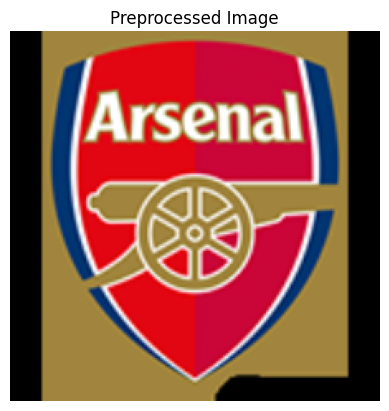

In [16]:
processed_img = preprocess_image(image_paths[80])

print("Shape:", processed_img.shape)
print("Min Pixel Value:", processed_img.min())
print("Max Pixel Value:", processed_img.max())

plt.imshow(processed_img)
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

In [13]:
processed_images = []

for path in image_paths:
    processed = preprocess_image(path)
    processed_images.append(processed)

print("Total Processed Images:", len(processed_images))

Total Processed Images: 100
